**'L’objectif'** est principalement de comprendre la structure des réseaux de

convolution, la dynamique de l’apprentissage, et l’influence des différents paramètres sur les performance d’un modèle.

# I - Préliminaires - Fonctions utiles

In [ ]:
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt
import itertools
import numpy as np

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Matrice de confusion',
                          cmap=plt.cm.Blues):
    """
    Affiche la matrice de confusion.
    Normalisation possible avec normalize=True.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')
    plt.show()


# II - Entraînement d'un CNN pour la classification sur CIFAR10

### II.1. Chargement et Dimensionnement de la base CIFAR10

In [ ]:
from keras import backend as K
print(K.backend())


tensorflow


In [ ]:
from keras.datasets import cifar10


Réduction de la taille du dataset (pour accélérer l'apprentissage), et standardisation des données

In [ ]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()
print('Dimension de la base d apprentissage CIFAR10 :', x_train_full.shape)
print('Dimension des vecteurs d étiquette de classe :', y_train_full.shape)
print('Dimension de la base de test CIFAR10 :', x_test_full.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Dimension de la base d apprentissage CIFAR10 : (50000, 32, 32, 3)
Dimension des vecteurs d étiquette de classe : (50000, 1)
Dimension de la base de test CIFAR10 : (10000, 32, 32, 3)


In [ ]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [ ]:
n_training_samples = 5000
n_other_samples    = 2000

def standardize(img_data):
    img_data_mean = np.mean(img_data, axis=(1,2), keepdims=True)
    img_data_std  = np.std (img_data, axis=(1,2), keepdims=True)
    img_data = (img_data - img_data_mean) / (img_data_std + 1e-8)
    return img_data

train_ids = np.random.choice(len(x_train_full), size=n_training_samples, replace=False)
other_ids = np.random.choice(len(x_test_full),  size=n_other_samples,    replace=False)

n_valid  = n_other_samples // 2
val_ids  = other_ids[:n_valid]
test_ids = other_ids[n_valid:]

x_train_initial, y_train = x_train_full[train_ids], y_train_full[train_ids]
x_val_initial,   y_val   = x_test_full[val_ids],    y_test_full[val_ids]
x_test_initial,  y_test  = x_test_full[test_ids],   y_test_full[test_ids]

x_train = standardize(x_train_initial.astype('float32'))
x_val   = standardize(x_val_initial  .astype('float32'))
x_test  = standardize(x_test_initial .astype('float32'))

print('Dimension de notre base d apprentissage :', x_train.shape)
print('Dimension des vecteurs d étiquette de classe :', y_train.shape)
print('Dimension de notre base de validation :', x_val.shape)
print('Dimension de notre base de test :', x_test.shape)


Dimension de notre base d apprentissage : (5000, 32, 32, 3)
Dimension des vecteurs d étiquette de classe : (5000, 1)
Dimension de notre base de validation : (1000, 32, 32, 3)
Dimension de notre base de test : (1000, 32, 32, 3)


/tmp/ipykernel_4018/1859751173.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axarr[k].set_title(classes[int(y_train[random_ids[k]])])


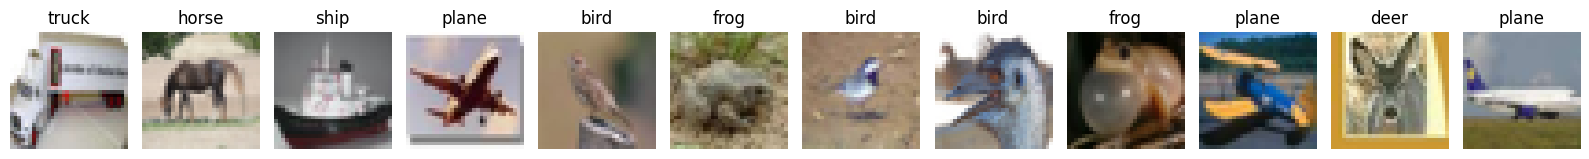

In [ ]:
n_display = 12
random_ids = np.random.choice(len(x_train), n_display, replace=False)
f, axarr = plt.subplots(1, n_display, figsize=(16, 2))
for k in range(n_display):
    axarr[k].imshow(x_train_initial[random_ids[k]])
    axarr[k].set_title(classes[int(y_train[random_ids[k]])])
    axarr[k].axis('off')
plt.tight_layout()
plt.show()


**Réponse 2 Structuration des données:**
1. Pourquoi divise-t-on la base en trois sous-ensembles {training, validation, test} ?

On sépare la base en trois parties pour donner un rôle différent à chaque ensemble.

**Le jeu training** sert à apprendre les paramètres du réseau, c’est-à-dire les poids et biais.

**Le jeu validation** sert à suivre les performances pendant l’apprentissage et à comparer des choix d’architecture ou d’hyperparamètres sans toucher au jeu de test.

**Le jeu test** sert uniquement à évaluer le modèle final sur des données jamais vues auparavant, afin d’obtenir une estimation plus honnête de sa capacité de généralisation.

    Cela permet de s’assurer que le modèle généralise bien et
    ne fait pas de surapprentissage.Cette séparation est essentielle
    pour garantir que le modèle ne mémorise pas les données et
    qu’il est capable de généraliser à de nouvelles données.

2. Que réalise la fonction standardize ? Quel est son intérêt ?

**La fonction standardize** centre et réduit chaque image. Elle soustrait la moyenne des pixels de l’image puis divise par son écart-type.

Son intérêt est de mettre les données sur une échelle plus homogène, ce qui stabilise l’apprentissage, accélère souvent la convergence, et évite qu’une image avec des valeurs globalement plus fortes domine inutilement l’optimisation.

### II.2. Architecture basique du réseau CNN

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

# ── Architecture basique ──────────────────────────────────────────────────
model = Sequential([
    # Couche 1 – Convolution  : 32 filtres 3×3, activation ReLU
    #   entrée : (32, 32, 3)  → sortie : (30, 30, 32)
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),

    # Couche 2 – Pooling Max 2×2
    #   entrée : (30, 30, 32) → sortie : (15, 15, 32)
    MaxPooling2D(pool_size=(2, 2)),

    # Couche 3 – Aplatissement du tenseur en vecteur
    #   entrée : (15, 15, 32) → sortie : (7200,)
    Flatten(),

    # Couche 4 – Couche dense / fully-connected
    #   entrée : (7200,)      → sortie : (64,)
    Dense(64, activation='relu'),

    # Couche 5 – Sortie : 10 classes, activation Softmax
    #   entrée : (64,)        → sortie : (10,)
    Dense(10, activation='softmax'),
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### II.3. Résumé de l'architecture

In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,410 (1.76 MB)

 Trainable params: 462,410 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

## Réponses – Section 3 : Architecture du réseau

### Question 1 – Qu'est-ce que les *trainable params*
Les **trainable parameters (paramètres entraînables)** sont les paramètres du réseau qui sont appris pendant l’entraînement, c’est-à-dire principalement les poids et les biais de chaque couche.



### Identification des couches

| Couche | Type | Rôle | Taille de sortie (H×W×C) |
|--------|------|------|----------------------------|
| 1 | `Conv2D(32, 3×3)` | Extraction de *features* locales par 32 filtres convolutifs 3×3 | 30×30×32 |
| 2 | `MaxPooling2D(2×2)` | Sous-échantillonnage : conserve le maximum dans chaque fenêtre 2×2, réduit la taille spatiale et apporte une invariance aux petites translations | 15×15×32 |
| 3 | `Flatten` | Transforme le tenseur 3D en vecteur 1D pour les couches denses | 7200 |
| 4 | `Dense(64)` | Couche entièrement connectée : combine toutes les features pour créer une représentation de haut niveau | 64 |
| 5 | `Dense(10, softmax)` | Couche de classification : produit une distribution de probabilité sur les 10 classes | 10 |

### Codage de la sortie

La classe prédite est codée en **probabilités via Softmax** : chaque neurone de sortie $i$ donne $P(\text{classe}=i \mid x)$, la somme valant 1. La classe prédite est celle de l'indice maximal (`argmax`).

### Comment les calcule-t-on ?



- **Conv2D(32, 3×3)** : `(3×3×3 + 1) × 32 = 896`  
  *(3×3 = taille filtre, ×3 = canaux RGB, +1 = biais, ×32 = nombre de filtres)*
- **Dense(64)** : `(7200 + 1) × 64 = 461 504`  
  *(7200 = taille entrée aplatie, +1 = biais, ×64 = neurones)*
- **Dense(10)** : `(64 + 1) × 10 = 650`

**Total ≈ 463 050 paramètres**

Dans ce réseau, le nombre total de paramètres entraînables est la somme des paramètres de toutes les couches;


### II.4. Entraînement du modèle

In [ ]:
from keras.callbacks import ModelCheckpoint
import time

# Hyperparamètres d'entraînement
BATCH_SIZE = 64
EPOCHS     = 20
LR         = 1e-3

# Compilation
model.compile(optimizer=Adam(learning_rate=LR),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Sauvegarde du meilleur modèle
filepath  = 'best_basic_model.keras'
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy',
                              save_best_only=True, verbose=1)

# Entraînement
t0 = time.time()
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint],
    verbose=1
)
print(f'Temps total : {time.time()-t0:.1f} s')


Epoch 1/20
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2127 - loss: 2.2349
Epoch 1: val_accuracy improved from None to 0.33300, saving model to best_basic_model.keras

Epoch 1: finished saving model to best_basic_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.2554 - loss: 2.0490 - val_accuracy: 0.3330 - val_loss: 1.8581
Epoch 2/20
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4179 - loss: 1.6836
Epoch 2: val_accuracy improved from 0.33300 to 0.35400, saving model to best_basic_model.keras

Epoch 2: finished saving model to best_basic_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.4214 - loss: 1.6553 - val_accuracy: 0.3540 - val_loss: 1.8036
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4794 - loss: 1.4727
Epoch 3: val_accuracy improved from 0.35400 to 0.44300, saving model to best_basic_model.keras

Epoch 3: finished saving model to best_basic_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.494

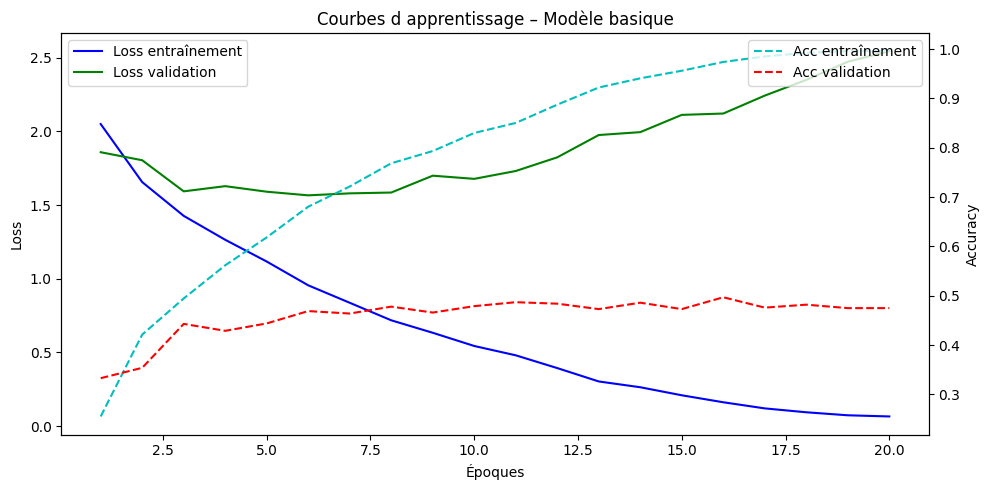

In [ ]:
# ── Courbes d'apprentissage ──────────────────────────────────────────────
history_dict = history.history

# Compatibilité Keras 2 / Keras 3 pour les clés
acc_key     = 'accuracy'     if 'accuracy'     in history_dict else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in history_dict else 'val_acc'

epochs_range = range(1, len(history_dict[acc_key]) + 1)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Époques')
ax1.set_ylabel('Loss')
ax1.plot(epochs_range, history_dict['loss'],     'b-', label='Loss entraînement')
ax1.plot(epochs_range, history_dict['val_loss'], 'g-', label='Loss validation')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy')
ax2.plot(epochs_range, history_dict[acc_key],     'c--', label='Acc entraînement')
ax2.plot(epochs_range, history_dict[val_acc_key], 'r--', label='Acc validation')
ax2.legend(loc='upper right')

plt.title('Courbes d apprentissage – Modèle basique')
fig.tight_layout()
plt.show()


## Réponses – Section 4 : Apprentissage

### Question 1 – Époque, étape, lot



Une epoch correspond à un passage complet sur toutes les données d’entraînement.

Un batch (lot) est un petit groupe de données utilisé pour entraîner le modèle à chaque itération.

Un step correspond au traitement d’un batch, c’est-à-dire une mise à jour des paramètres du modèle.



>Si on a 5000 images et batch_size = 32, alors le nombre de steps par epoch est environ 5000 / 32 ≈ 157


### Question 2 – Effet de la taille de lot

| batch_size | Temps/étape | Temps/époque | Courbes |
|-----------|-------------|--------------|--------|
| Petit (8-16) | Court | Long (+ d'étapes) | Gradient bruité → convergence plus chaotique mais souvent meilleure généralisation |
| Grand (128-256) | Long | Court (- d'étapes) | Gradient lisse → convergence rapide mais risque de sur-apprentissage et de minima « aigus » |

Un `batch_size` de 32 à 64 est souvent un bon compromis.

### Question 3 – Comparaison des optimiseurs

| Optimiseur | Principe | Avantages | Inconvénients |
|-----------|----------|-----------|---------------|
| **SGD** | Mise à jour par gradient stochastique pur : `w ← w - lr·∇L` | Simple, bien compris théoriquement | Lent à converger, sensible au learning rate |
| **SGD + Momentum** | Accumule une vélocité exponentiellement pondérée des gradients passés | Amortit les oscillations, accélère la descente dans les directions cohérentes | Hyperparamètre supplémentaire (momentum, typiquement 0.9) |
| **Adam** | Adapte le learning rate *par paramètre* (moyenne des gradients + variance) | Converge rapidement, robuste aux choix de lr | Peut généraliser moins bien que SGD + momentum sur certains jeux de données |

> En pratique pour ce TP, **Adam** donnera la convergence la plus rapide et sera retenu.


#### Comparaison pratique des optimiseurs (SGD, SGD+Momentum, Adam)


=== Entraînement avec SGD ===
  Val accuracy finale : 32.7 %

=== Entraînement avec SGD+Momentum ===
  Val accuracy finale : 49.3 %

=== Entraînement avec Adam ===
  Val accuracy finale : 48.5 %


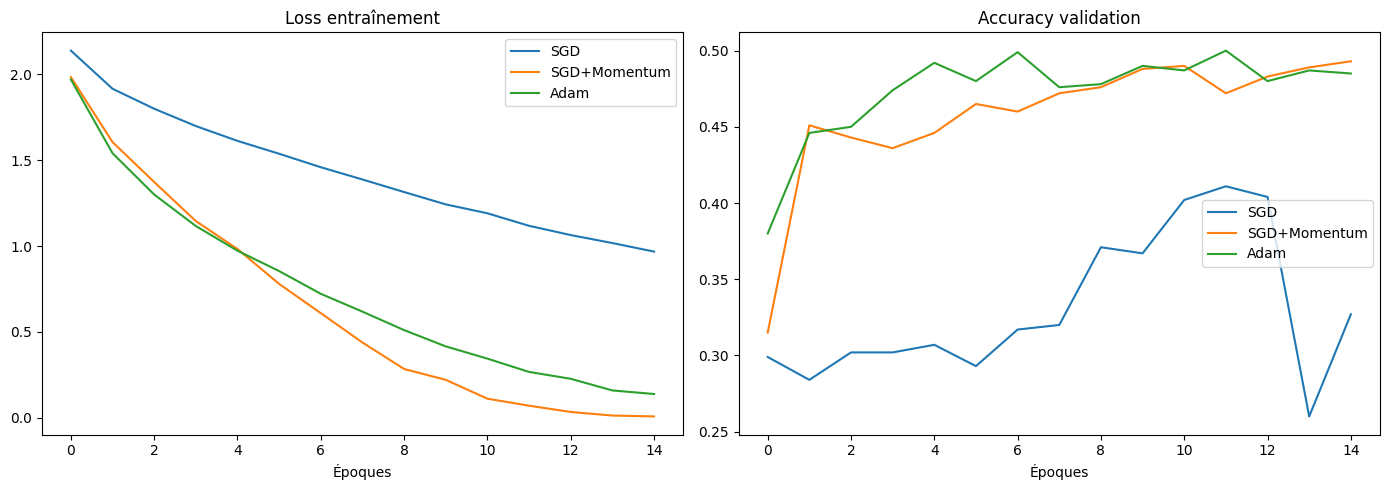

In [ ]:
from keras.optimizers import SGD

def build_basic_model():
    m = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax'),
    ])
    return m

optimizers = {
    'SGD':          SGD(learning_rate=0.01),
    'SGD+Momentum': SGD(learning_rate=0.01, momentum=0.9),
    'Adam':         Adam(learning_rate=0.001),
}

histories_opt = {}
for name, opt in optimizers.items():
    print(f'\n=== Entraînement avec {name} ===')
    m = build_basic_model()
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train, y_train, batch_size=64, epochs=15,
              validation_data=(x_val, y_val), verbose=0)
    histories_opt[name] = h.history
    val_acc_k = 'val_accuracy' if 'val_accuracy' in h.history else 'val_acc'
    print(f'  Val accuracy finale : {h.history[val_acc_k][-1]*100:.1f} %')

# ── Tracé comparatif ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in histories_opt.items():
    acc_k     = 'accuracy'     if 'accuracy'     in hist else 'acc'
    val_acc_k = 'val_accuracy' if 'val_accuracy' in hist else 'val_acc'
    axes[0].plot(hist['loss'],      label=name)
    axes[1].plot(hist[val_acc_k],   label=name)

axes[0].set_title('Loss entraînement'); axes[0].set_xlabel('Époques'); axes[0].legend()
axes[1].set_title('Accuracy validation'); axes[1].set_xlabel('Époques'); axes[1].legend()
plt.tight_layout(); plt.show()


## Réponses – Section 5 : Hyperparamètres

Un **hyperparamètre** est un paramètre fixé *avant* l'entraînement et non appris par le réseau.

| Hyperparamètre | Valeur typique | Influence |
|----------------|---------------|--------|
| `n_training_samples` | 5 000 | Plus il est grand, meilleure est la généralisation mais plus long est l'entraînement |
| Nombre de filtres Conv2D | 32 | Capacité d'extraction de features ; augmenter → plus de features mais plus de paramètres |
| Taille du filtre | 3×3 | Champ récepteur local ; 3×3 est le standard |
| `padding` | 'valid' | 'same' conserve les dimensions spatiales ; 'valid' les réduit |
| Taille de pool | 2×2 | Facteur de sous-échantillonnage ; réduit la taille spatiale |
| Neurones Dense | 64 | Capacité de représentation ; trop peu → sous-apprentissage |
| `activation` | 'relu' | Fonction d'activation ; ReLU est le standard pour les couches cachées |
| `batch_size` | 64 | Compromis bruit/vitesse de convergence (voir Section 4) |
| `epochs` | 20 | Nombre de passages sur les données ; trop → surapprentissage |
| `learning_rate` | 1e-3 | Taille du pas de descente de gradient ; critique pour la convergence |
| Optimiseur | Adam | Algorithme de mise à jour des poids (voir Section 4) |
| Taux de dropout | 0.25 / 0.5 | Fraction des neurones désactivés aléatoirement → régularisation |

Les hyperparamètres les plus influents sont généralement : `learning_rate`, l'architecture (nombre de couches/filtres) et `batch_size`.


## Section 6 : Approfondissement du modèle – CNN multi-couches

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam

# ── Architecture approfondie ──────────────────────────────────────────────
#
#  Bloc 1 : 2 × Conv(32) → MaxPool → Dropout
#  Bloc 2 : 2 × Conv(64) → MaxPool → Dropout
#  Tête   : Flatten → Dense(256) → Dropout → Dense(10, softmax)
#
# Calcul des tailles :
#  entrée          : 32×32×3
#  après Conv(same): 32×32×32  (padding='same' conserve H,W)
#  après Conv(same): 32×32×32
#  après MaxPool   : 16×16×32
#  après Conv(same): 16×16×64
#  après Conv(same): 16×16×64
#  après MaxPool   :  8×8×64  = 4096 valeurs

def build_deep_model():
    m = Sequential(name='CNN_profond')

    # ── Bloc convolutif 1 ──────────────────────────
    m.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
    m.add(BatchNormalization())
    m.add(Conv2D(32, (3,3), padding='same', activation='relu'))
    m.add(BatchNormalization())
    m.add(MaxPooling2D((2,2)))
    m.add(Dropout(0.25))

    # ── Bloc convolutif 2 ──────────────────────────
    m.add(Conv2D(64, (3,3), padding='same', activation='relu'))
    m.add(BatchNormalization())
    m.add(Conv2D(64, (3,3), padding='same', activation='relu'))
    m.add(BatchNormalization())
    m.add(MaxPooling2D((2,2)))
    m.add(Dropout(0.25))

    # ── Bloc convolutif 3 ──────────────────────────
    m.add(Conv2D(128, (3,3), padding='same', activation='relu'))
    m.add(BatchNormalization())
    m.add(MaxPooling2D((2,2)))
    m.add(Dropout(0.25))

    # ── Tête classifiante ──────────────────────────
    m.add(Flatten())
    m.add(Dense(256, activation='relu'))
    m.add(BatchNormalization())
    m.add(Dropout(0.5))
    m.add(Dense(10, activation='softmax'))

    return m

deep_model = build_deep_model()
deep_model.summary()


Model: "CNN_profond"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

deep_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep = [
    ModelCheckpoint('best_deep_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
]

history_deep = deep_model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=callbacks_deep,
    verbose=1
)


Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 484ms/step - accuracy: 0.2494 - loss: 2.6190 - val_accuracy: 0.1290 - val_loss: 2.7678 - learning_rate: 0.0010
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 489ms/step - accuracy: 0.3440 - loss: 1.9921 - val_accuracy: 0.1300 - val_loss: 3.3278 - learning_rate: 0.0010
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 482ms/step - accuracy: 0.4214 - loss: 1.6906 - val_accuracy: 0.1990 - val_loss: 2.4602 - learning_rate: 0.0010
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 473ms/step - accuracy: 0.4732 - loss: 1.5281 - val_accuracy: 0.3310 - val_loss: 2.0112 - learning_rate: 0.0010
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 471ms/step - accuracy: 0.5052 - loss: 1.3977 - val_accuracy: 0.4030 - val_loss: 1.6582 - learning_rate: 0.0010
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 477ms/step - accuracy: 0.5416 - loss: 1.2921 - val_accuracy: 0.5030 - val_loss: 1.3859 - learning_rate: 0.0010
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 457ms/step - accuracy: 0.5660 - loss: 1.

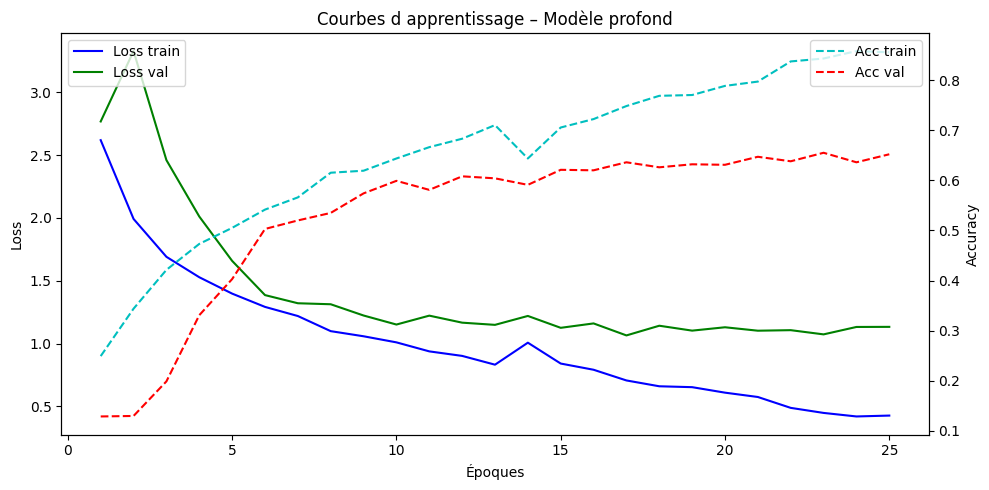

In [ ]:
# ── Courbes d'apprentissage – Modèle profond ──────────────────────────────
hd = history_deep.history
acc_k     = 'accuracy'     if 'accuracy'     in hd else 'acc'
val_acc_k = 'val_accuracy' if 'val_accuracy' in hd else 'val_acc'

ep = range(1, len(hd[acc_k]) + 1)
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(ep, hd['loss'],     'b-',  label='Loss train')
ax1.plot(ep, hd['val_loss'], 'g-',  label='Loss val')
ax1.set_xlabel('Époques'); ax1.set_ylabel('Loss'); ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(ep, hd[acc_k],     'c--', label='Acc train')
ax2.plot(ep, hd[val_acc_k], 'r--', label='Acc val')
ax2.set_ylabel('Accuracy'); ax2.legend(loc='upper right')
plt.title('Courbes d apprentissage – Modèle profond')
fig.tight_layout(); plt.show()


### Évaluation du modèle profond sur le jeu de test

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
Précision sur le jeu de test : 66.90 %


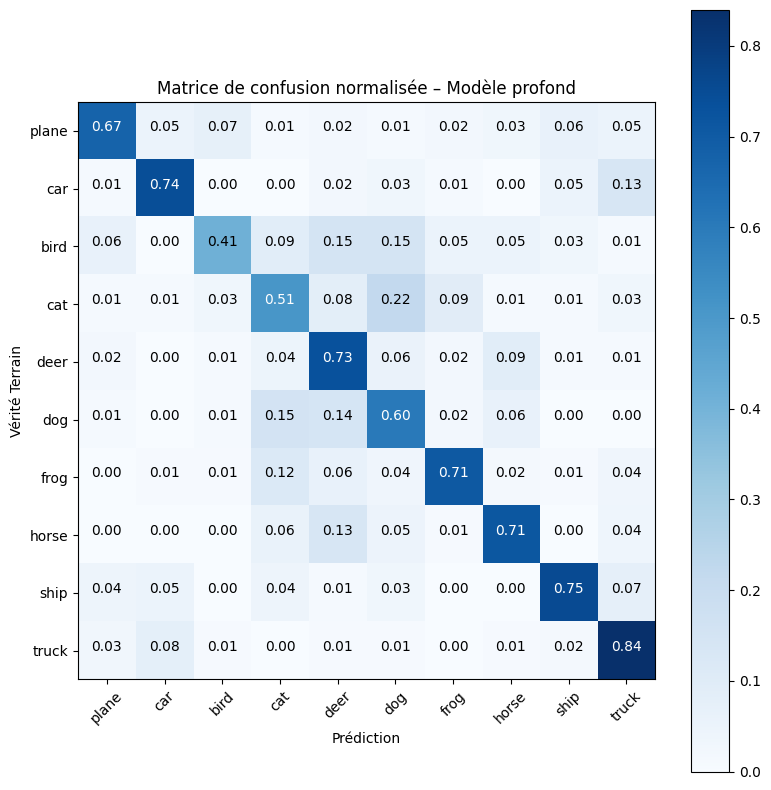

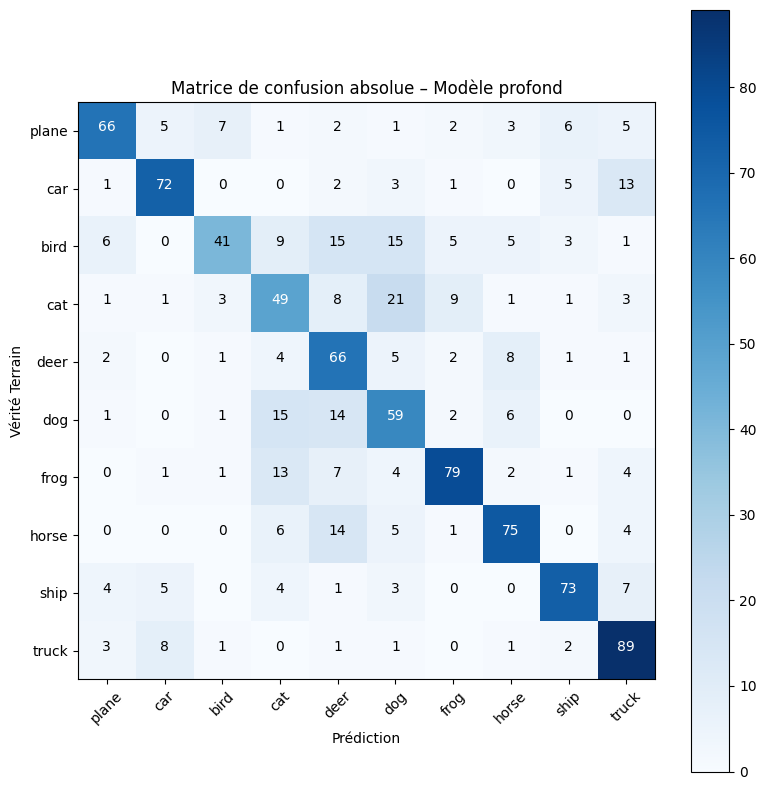

In [ ]:
from sklearn.metrics import confusion_matrix as sk_cm

y_pred_deep = np.argmax(deep_model.predict(x_test), axis=1)
y_true      = y_test.flatten()

cm_deep = sk_cm(y_true, y_pred_deep)

test_acc = np.sum(y_pred_deep == y_true) / len(y_true)
print(f'Précision sur le jeu de test : {test_acc*100:.2f} %')

plot_confusion_matrix(cm_deep, classes, normalize=True,
                      title='Matrice de confusion normalisée – Modèle profond')
plot_confusion_matrix(cm_deep, classes,
                      title='Matrice de confusion absolue – Modèle profond')


###Section 6 :Approfondissement du modèle
1. Comment améliorer les performances ?
On peut empiler plusieurs couches convolutives avant le pooling, par exemple :

Conv2D(32) → Conv2D(32) → MaxPool
Conv2D(64) → Conv2D(64) → MaxPool
Flatten
Dense(128)
Dropout
Dense(10, softmax)

Cela permet au réseau d’apprendre des caractéristiques de plus en plus abstraites : d’abord contours et textures, puis parties d’objets, puis objets plus complexes.

2. Que présenter quand le modèle final est choisi ?
Il faut montrer :

le schéma ou résumé du réseau,
les hyperparamètres utilisés,
les courbes loss/val_loss et acc/val_acc,
la matrice de confusion.

3. Critique du modèle
Avantages :

simple à comprendre ;
relativement rapide à entraîner ;
adapté à CIFAR10 en petite taille.

Limites :

réseau de base trop peu profond pour capturer des motifs complexes ;
performances limitées sans augmentation de données ;
sensible aux choix d’hyperparamètres ;
apprentissage sur petit sous-ensemble, donc généralisation limitée.

## Section 7 : Sur-apprentissage (Overfitting)



### Question 1 – Comment observer le sur-apprentissage sur les courbes ?

| Indicateur observé                                        | Interprétation                                                            |
| --------------------------------------------------------- | ------------------------------------------------------------------------- |
| La **loss d’entraînement** continue de diminuer           | Le modèle apprend de mieux en mieux les données d’entraînement            |
| La **loss de validation** cesse de diminuer puis augmente | Le modèle commence à moins bien généraliser sur des données nouvelles     |
| L’**accuracy d’entraînement** continue d’augmenter        | Le réseau devient très performant sur la base d’entraînement              |
| L’**accuracy de validation** stagne ou diminue            | Les performances sur des données non vues n’évoluent plus ou se dégradent |
| L’écart entre **train** et **validation** se creuse       | Signe typique de sur-apprentissage                                        |

**Conclusion :** le sur-apprentissage apparaît lorsque le modèle continue à s’améliorer sur l’entraînement, mais se dégrade sur la validation.

---

### Question 2 – Mécanismes anti-surapprentissage

| Mécanisme               | Principe                                                                    | Effet attendu                                                  |
| ----------------------- | --------------------------------------------------------------------------- | -------------------------------------------------------------- |
| **Dropout**             | Désactive aléatoirement une partie des neurones pendant l’entraînement      | Réduit la mémorisation excessive et améliore la généralisation |
| **Batch Normalization** | Normalise les activations intermédiaires                                    | Stabilise l’apprentissage et apporte une légère régularisation |
| **Early Stopping**      | Arrête l’entraînement quand la performance de validation ne s’améliore plus | Évite de continuer après le début du sur-apprentissage         |
| **Régularisation L2**   | Ajoute une pénalisation sur les poids trop grands                           | Limite les poids excessifs et rend le modèle plus simple       |
| **Data Augmentation**   | Crée artificiellement de nouvelles images à partir des images existantes    | Augmente la diversité des données et réduit l’overfitting      |
| **Réduction du modèle** | Diminue le nombre de paramètres ou la profondeur du réseau                  | Réduit la capacité du réseau à mémoriser les données           |



> Le sur-apprentissage se détecte par un écart croissant entre les performances d’entraînement et de validation. Pour le limiter, on peut utiliser des techniques de régularisation comme le dropout, la pénalisation L2, l’arrêt anticipé, l’augmentation de données ou encore une architecture plus simple.



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


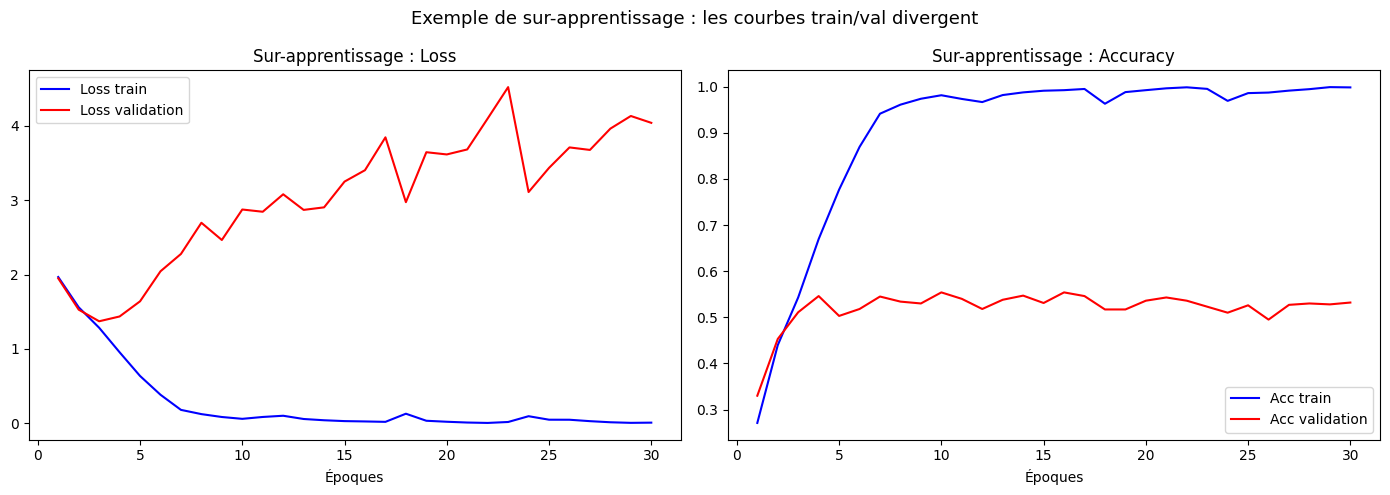

Acc train finale : 99.8 %  |  Acc val finale : 53.2 %
-> Écart important = signe de sur-apprentissage


In [ ]:
# ── Démonstration de sur-apprentissage (modèle trop grand, pas de régularisation) ──
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

overfit_model = Sequential([
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(512, activation='relu'),   # grande couche, pas de dropout
    Dense(512, activation='relu'),
    Dense(10, activation='softmax'),
])

overfit_model.compile(optimizer=Adam(1e-3),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_overfit = overfit_model.fit(
    x_train, y_train, batch_size=64, epochs=30,
    validation_data=(x_val, y_val), verbose=0
)

# ── Affichage des courbes de sur-apprentissage ──────────────────────────
ho = history_overfit.history
acc_k     = 'accuracy'     if 'accuracy'     in ho else 'acc'
val_acc_k = 'val_accuracy' if 'val_accuracy' in ho else 'val_acc'
ep        = range(1, len(ho[acc_k]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ep, ho['loss'],     'b-', label='Loss train')
axes[0].plot(ep, ho['val_loss'], 'r-', label='Loss validation')
axes[0].set_title('Sur-apprentissage : Loss'); axes[0].set_xlabel('Époques')
axes[0].legend()

axes[1].plot(ep, ho[acc_k],     'b-', label='Acc train')
axes[1].plot(ep, ho[val_acc_k], 'r-', label='Acc validation')
axes[1].set_title('Sur-apprentissage : Accuracy'); axes[1].set_xlabel('Époques')
axes[1].legend()

plt.suptitle('Exemple de sur-apprentissage : les courbes train/val divergent', fontsize=13)
fig.tight_layout(); plt.show()

final_train_acc = ho[acc_k][-1]
final_val_acc   = ho[val_acc_k][-1]
print(f'Acc train finale : {final_train_acc*100:.1f} %  |  Acc val finale : {final_val_acc*100:.1f} %')
print('-> Écart important = signe de sur-apprentissage')


In [ ]:
# ── Remède : même architecture AVEC régularisation ──────────────────────
from keras.layers import Dropout, BatchNormalization
from keras import regularizers

regularized_model = Sequential([
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.5),
    Dense(10, activation='softmax'),
])

regularized_model.compile(optimizer=Adam(1e-3),
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

history_reg = regularized_model.fit(
    x_train, y_train, batch_size=64, epochs=30,
    validation_data=(x_val, y_val), verbose=0
)

# ── Comparaison côte-à-côte ──────────────────────────────────────────────
hr = history_reg.history
acc_k     = 'accuracy'     if 'accuracy'     in hr else 'acc'
val_acc_k = 'val_accuracy' if 'val_accuracy' in hr else 'val_acc'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, ho['val_loss'], 'r--', label='Val loss – sans régularisation')
axes[0].plot(range(1,len(hr['val_loss'])+1), hr['val_loss'], 'g-', label='Val loss – avec régularisation')
axes[0].set_title('Val Loss : effet de la régularisation')
axes[0].set_xlabel('Époques'); axes[0].legend()

axes[1].plot(ep, ho[val_acc_k], 'r--', label='Val acc – sans régularisation')
axes[1].plot(range(1,len(hr[val_acc_k])+1), hr[val_acc_k], 'g-', label='Val acc – avec régularisation')
axes[1].set_title('Val Accuracy : effet de la régularisation')
axes[1].set_xlabel('Époques'); axes[1].legend()

fig.tight_layout(); plt.show()


# III - Test et Évaluation du modèle en prédiction

### III.1. Test du modèle sur les données de test

In [ ]:
n_display = 12
random_ids = np.random.choice(len(x_test), n_display, replace=False)
pred = np.argmax(deep_model.predict(x_test[random_ids]), axis=1)

f, axarr = plt.subplots(1, n_display, figsize=(16, 2))
for k in range(n_display):
    axarr[k].imshow(x_test_initial[random_ids[k]])
    true_label = classes[int(y_test[random_ids[k]])]
    pred_label = classes[pred[k]]
    color = 'green' if true_label == pred_label else 'red'
    axarr[k].set_title(pred_label, color=color, fontsize=8)
    axarr[k].axis('off')
plt.suptitle('Prédictions (vert=correct, rouge=erreur)')
plt.tight_layout(); plt.show()


In [ ]:
def accuracy_per_class(model, x, y, label='test'):
    n_classes = len(classes)
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    pred = np.argmax(model.predict(x), axis=1)
    for i in range(len(y)):
        cm[int(y[i]), pred[i]] += 1
    print(f'\nPrécision par classe ({label}) :')
    print('{:<10} {:^12}'.format('Classe', 'Précision (%)'))
    total_correct = 0
    for i in range(n_classes):
        class_total   = cm[i, :].sum()
        class_correct = cm[i, i]
        total_correct += class_correct
        pct = 100.0 * class_correct / class_total if class_total > 0 else 0
        print('{:<10} {:^12.2f}'.format(classes[i], pct))
    test_acc = 100.0 * total_correct / len(y)
    print(f'Précision globale : {test_acc:.2f} %')
    return cm

cm_final = accuracy_per_class(deep_model, x_test, y_test)

plot_confusion_matrix(cm_final, classes, normalize=True,
                      title='Matrice de confusion normalisée – Modèle final')
plot_confusion_matrix(cm_final, classes,
                      title='Matrice de confusion absolue – Modèle final')


### II.5. Entraînement avec points d'arrêt et reprises

Pour des entraînements plus longs, il est essentiel de sauvegarder les modèles intermédiaires.
L'objet `ModelCheckpoint` (utilisé dans II.4 et Section 6) sauvegarde automatiquement le meilleur modèle.
Pour recharger le modèle :


In [ ]:
from keras.models import load_model
import pathlib

filepath_deep = 'best_deep_model.keras'
if pathlib.Path(filepath_deep).exists():
    loaded_model = load_model(filepath_deep)
    print('Modèle chargé depuis', filepath_deep)
    loaded_model.summary()
else:
    print('Fichier non trouvé – le modèle reste celui entraîné en mémoire.')
    loaded_model = deep_model


# IV - Visualisation des zones d'activation



### Question 1 – Interprétation des cartes d’activation de la première couche

| Élément observé             | Interprétation                                                                      |
| --------------------------- | ----------------------------------------------------------------------------------- |
| Première couche convolutive | Elle détecte des **features simples** de bas niveau                                 |
| Une carte d’activation      | Correspond à la réponse d’un **filtre** particulier                                 |
| Motifs détectés             | Contours horizontaux, verticaux, diagonaux, textures simples, variations de couleur |
| Zones claires / brillantes  | Régions où le filtre répond fortement, donc où le motif est présent                 |
| Ensemble des cartes         | Donne une vision des régions importantes de l’image pour les premiers traitements   |

### Question 2 – Cartes des couches profondes

| Aspect                      | Interprétation                                                                    |
| --------------------------- | --------------------------------------------------------------------------------- |
| Couches profondes           | Elles apprennent des **features plus abstraites**                                 |
| Résolution spatiale         | Elle diminue à cause des opérations de pooling                                    |
| Nature des motifs détectés  | On passe de contours simples à des **parties d’objets** ou motifs complexes       |
| Lisibilité visuelle         | Les cartes sont plus difficiles à interpréter directement                         |
| Rôle dans la classification | Elles mettent en évidence les régions les plus utiles pour distinguer les classes |

### Question 3 – Évolution des cartes au cours de l’entraînement

| Moment de l’entraînement | Observation                                                                                                      |
| ------------------------ | ---------------------------------------------------------------------------------------------------------------- |
| Début                    | Les poids étant presque aléatoires, les cartes sont diffuses et peu informatives                                 |
| Milieu                   | Certains filtres commencent à se spécialiser sur des contours, textures ou zones caractéristiques                |
| Fin                      | Les activations deviennent plus nettes, plus sélectives et se concentrent sur les régions pertinentes de l’objet |
| Interprétation globale   | Le réseau apprend progressivement à extraire des caractéristiques de plus en plus utiles pour la classification  |

### Conclusion

| Idée principale                   | Explication                                                  |
| --------------------------------- | ------------------------------------------------------------ |
| Première couche                   | Détecte des motifs simples et locaux                         |
| Couches profondes                 | Capturent des représentations plus riches et plus abstraites |
| Évolution pendant l’apprentissage | Montre la spécialisation progressive des filtres             |



In [ ]:
from keras.models import Model

# ── Cartes d'activation de la 1ère couche Conv ──────────────────────────
layer_idx = 1  # 0 = entrée, 1 = première Conv2D (après BN il faut ajuster)
# On cherche la première couche Conv2D
conv_layer_indices = [i for i, l in enumerate(deep_model.layers)
                      if 'conv2d' in l.name]
print('Couches Conv2D :', [(i, deep_model.layers[i].name) for i in conv_layer_indices])


In [ ]:
# ── Visualisation des cartes pour plusieurs couches ──────────────────────

def show_activation_maps(model, x_test_std, x_test_orig, sample_ids, layer_name, title):
    """Affiche les images originales et leurs cartes d'activation pour une couche donnée."""
    act_model = Model(inputs=model.inputs,
                      outputs=model.get_layer(layer_name).output)
    feature_maps = act_model.predict(x_test_std)

    n = len(sample_ids)
    fig, axes = plt.subplots(2, n, figsize=(n*2, 4))
    fig.suptitle(title, fontsize=12)

    for k, idx in enumerate(sample_ids):
        # Image originale
        axes[0, k].imshow(x_test_orig[idx])
        axes[0, k].set_title(classes[int(y_test[idx])], fontsize=8)
        axes[0, k].axis('off')

        # Carte d'activation (somme des canaux positifs)
        fmap = feature_maps[idx]
        fmap_pos = np.maximum(fmap, 0)
        mask = np.sum(fmap_pos, axis=-1)
        if mask.max() > 0:
            mask = mask / mask.max()
        axes[1, k].imshow(mask, cmap='hot')
        axes[1, k].axis('off')

    plt.tight_layout(); plt.show()


n_display_act = 8
rand_ids = np.random.choice(len(x_test), n_display_act, replace=False)

# Couche 1 (features bas niveau)
first_conv = deep_model.layers[conv_layer_indices[0]].name
show_activation_maps(deep_model, x_test, x_test_initial, rand_ids,
                     first_conv, f'Cartes d activation – {first_conv} (bas niveau)')

# Couche médiane
mid_idx = conv_layer_indices[len(conv_layer_indices)//2]
mid_conv = deep_model.layers[mid_idx].name
show_activation_maps(deep_model, x_test, x_test_initial, rand_ids,
                     mid_conv, f'Cartes d activation – {mid_conv} (niveau intermédiaire)')

# Dernière couche conv
last_conv = deep_model.layers[conv_layer_indices[-1]].name
show_activation_maps(deep_model, x_test, x_test_initial, rand_ids,
                     last_conv, f'Cartes d activation – {last_conv} (haut niveau)')


In [ ]:
# ── Évolution des cartes au cours de l'entraînement ──────────────────────
# On réentraîne le modèle brièvement en sauvegardant les poids à différentes époques

from keras.callbacks import LambdaCallback

epoch_weights = {}  # époque → poids sauvegardés
save_at = [1, 5, 10, 20]

def save_weights_cb(epoch, logs):
    if (epoch + 1) in save_at:
        epoch_weights[epoch + 1] = [w.copy() for w in evolution_model.get_weights()]
        print(f'  Poids sauvegardés à l époque {epoch+1}')

# Nouveau modèle léger pour l'évolution
evolution_model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax'),
])
evolution_model.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

evolution_model.fit(x_train, y_train, batch_size=64, epochs=max(save_at),
                    validation_data=(x_val, y_val), verbose=0,
                    callbacks=[LambdaCallback(on_epoch_end=save_weights_cb)])
print('Entraînement terminé.')


In [ ]:
# Affichage de l'évolution des cartes d'activation
sample_id = np.random.randint(len(x_test))
first_conv_ev = evolution_model.layers[0].name

fig, axes = plt.subplots(2, len(save_at)+1, figsize=((len(save_at)+1)*3, 6))
axes[0, 0].imshow(x_test_initial[sample_id])
axes[0, 0].set_title('Image originale', fontsize=9)
axes[0, 0].axis('off')
axes[1, 0].axis('off')

act_model_ev = Model(inputs=evolution_model.inputs,
                     outputs=evolution_model.get_layer(first_conv_ev).output)

for col, ep_saved in enumerate(save_at, start=1):
    evolution_model.set_weights(epoch_weights[ep_saved])
    fmaps = act_model_ev.predict(x_test[sample_id:sample_id+1])
    fmap_pos = np.maximum(fmaps[0], 0)
    mask = np.sum(fmap_pos, axis=-1)
    if mask.max() > 0:
        mask = mask / mask.max()

    axes[0, col].imshow(x_test_initial[sample_id])
    axes[0, col].set_title(f'Époque {ep_saved}', fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(mask, cmap='hot')
    axes[1, col].set_title(f'Activation ep.{ep_saved}', fontsize=9)
    axes[1, col].axis('off')

plt.suptitle('Évolution des cartes d activation au cours de l entraînement', fontsize=12)
plt.tight_layout(); plt.show()




## Conclusion
> Ce TP a permis de mettre en évidence le fonctionnement d’un réseau de neurones convolutif pour la classification d’images, ainsi que l’importance du choix de l’architecture, des hyperparamètres et des techniques de régularisation pour obtenir un modèle performant et capable de bien généraliser.


| Point étudié                    | Bilan                                                                                                                                                                                 |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Structuration des données**   | La séparation en ensembles **train / validation / test** permet d’entraîner, d’ajuster et d’évaluer correctement le modèle. La normalisation des données facilite l’apprentissage.    |
| **Architecture CNN**            | Le TP a permis de comprendre le rôle des principales couches d’un réseau convolutionnel : **convolution**, **pooling**, **flatten** et **dense**.                                     |
| **Dynamique d’apprentissage**   | L’étude du **batch size** et des différents **optimiseurs** a montré leur influence sur la vitesse de convergence, la stabilité de l’entraînement et la qualité des résultats.        |
| **Hyperparamètres**             | Les hyperparamètres jouent un rôle central dans les performances du modèle, sa capacité d’apprentissage et sa généralisation.                                                         |
| **Approfondissement du modèle** | L’utilisation d’un réseau plus profond, organisé en plusieurs blocs convolutifs avec **Batch Normalization** et **Dropout**, permet d’améliorer sensiblement les performances.        |
| **Sur-apprentissage**           | Le TP a montré comment détecter l’**overfitting** sur les courbes d’apprentissage et quelles techniques permettent de le limiter.                                                     |
| **Cartes d’activation**         | L’analyse des cartes d’activation aide à comprendre ce que le réseau apprend à différents niveaux de profondeur, depuis les motifs simples jusqu’aux représentations plus abstraites. |





